In [1]:
#Bibliotecas do Projeto
import pandas as pd
import numpy  as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from plotly.subplots         import make_subplots
from haversine               import haversine
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier
from sklearn.svm             import SVC
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import balanced_accuracy_score, precision_score
from sklearn.metrics         import precision_recall_curve
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import recall_score, f1_score, make_scorer, cohen_kappa_score , roc_auc_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold



In [2]:
#Carregando o dataset para o python

clientes = pd.read_csv('C:/Users/HUDSON.SANTOS/Desktop/TCC/base/olist_customers_dataset.csv')
geolocalizacao = pd.read_csv('C:/Users/HUDSON.SANTOS/Desktop/TCC/base/olist_geolocation_dataset.csv')
itens = pd.read_csv('C:/Users/HUDSON.SANTOS/Desktop/TCC/base/olist_order_items_dataset.csv')
pagamentos = pd.read_csv('C:/Users/HUDSON.SANTOS/Desktop/TCC/base/olist_order_payments_dataset.csv')
pedidos = pd.read_csv('C:/Users/HUDSON.SANTOS/Desktop/TCC/base/olist_orders_dataset.csv')
produtos = pd.read_csv('C:/Users/HUDSON.SANTOS/Desktop/TCC/base/olist_products_dataset.csv')
vendedores = pd.read_csv('C:/Users/HUDSON.SANTOS/Desktop/TCC/base/olist_sellers_dataset.csv')
categoria_produto = pd.read_csv('C:/Users/HUDSON.SANTOS/Desktop/TCC/base/product_category_name_translation.csv')
reviews = pd.read_csv('C:/Users/HUDSON.SANTOS/Desktop/TCC/base/olist_order_reviews_dataset.csv')

Quais variáveis (features) eu devo considerar?

O que precisa ser agrupado?

Variáveis (features):

Clientes (Customers):
customer_zip_code_prefix /// customer_city /// customer_state

Geolocalização (Geolocation):
geolocation_lat /// geolocation_lng ///


Itens do Pedido (Order_Items):
shipping_limit_date /// price /// freight_value ///


Pagamentos (Payments):
N/A (após o envio do pedido)

Avaliações (Order_Reviews):
N/A (após o envio do pedido)

Pedidos (Orders):
order_id /// customer_id /// order_purchase_timestamp /// order_approved_at /// order_delivered_carrier_date /// order_delivered_customer_date /// order_estimated_delivery_date ///


Produtos (Products):
product_category_name /// product_weight_g /// product_length_cm /// product_height_cm /// product_width_cm ///


Vendedores (Sellers):
seller_zip_code_prefix /// seller_city /// seller_state


In [3]:
#Vamos começar verificando a tabela de geolocalizacao

geolocalizacao.head(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [4]:
geolocalizacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [5]:
#Vemos que existem bastante códigos para o mesmo endereço, para consternar essa redundancia, irei usar somente uma latitude e longitude de cada um
geolocalizacao['geolocation_zip_code_prefix'].value_counts()

geolocation_zip_code_prefix
24220    1146
24230    1102
38400     965
35500     907
11680     879
         ... 
57140       1
57604       1
57750       1
57730       1
57000       1
Name: count, Length: 19015, dtype: int64

In [6]:
#Tirando as duplicatas
geolocalizacao.drop_duplicates('geolocation_zip_code_prefix', inplace = True)

In [7]:
geolocalizacao.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19015 entries, 0 to 999846
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
 3   geolocation_city             19015 non-null  object 
 4   geolocation_state            19015 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 891.3+ KB


Após a limpeza da tabela geolocalizacao, vamos analisar a tabela de clientes.

Essa analise se faz necessária, pois não da para juntar o dataset bruto, devido a valores repetidos

In [8]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


como nosso foco será realizar as previsões a nivel de pedido, irei retirar a coluna customer_unique_id

In [9]:
clientes_merge = clientes.merge(geolocalizacao.loc[:,['geolocation_lat','geolocation_lng', 'geolocation_zip_code_prefix']],
                                how = 'left', left_on = 'customer_zip_code_prefix' , right_on = 'geolocation_zip_code_prefix')

In [10]:
clientes_merge.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng,geolocation_zip_code_prefix
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.509897,-47.397866,14409.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.726853,-46.545746,9790.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.527788,-46.660310,1151.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.496930,-46.185352,8775.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.987222,-47.151073,13056.0


Como já temos a latitude e a longitude dos pedidos, a ultima coluna não se faz mais relevante, portanto irei remove-la

In [11]:
del clientes_merge['geolocation_zip_code_prefix']

In [12]:
clientes_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               99441 non-null  object 
 1   customer_unique_id        99441 non-null  object 
 2   customer_zip_code_prefix  99441 non-null  int64  
 3   customer_city             99441 non-null  object 
 4   customer_state            99441 non-null  object 
 5   geolocation_lat           99163 non-null  float64
 6   geolocation_lng           99163 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 5.3+ MB


Agora iremos realizar a integração com a nossa tabela de pedidos

In [13]:
pedidos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [14]:
pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [15]:
#Vemos que temos alguns valores nulos, por serem uma quantidade pequena, irei descartar os valores
pedidos.dropna(inplace = True)
pedidos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96461 non-null  object
 1   customer_id                    96461 non-null  object
 2   order_status                   96461 non-null  object
 3   order_purchase_timestamp       96461 non-null  object
 4   order_approved_at              96461 non-null  object
 5   order_delivered_carrier_date   96461 non-null  object
 6   order_delivered_customer_date  96461 non-null  object
 7   order_estimated_delivery_date  96461 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [16]:
# Antes de continuarmos vamos realizar as transformações em data das variaveis

pedidos['order_purchase_timestamp'] = pd.to_datetime(pedidos['order_purchase_timestamp'])
pedidos['order_delivered_customer_date'] = pd.to_datetime(pedidos['order_delivered_customer_date'])
pedidos['order_estimated_delivery_date'] = pd.to_datetime(pedidos['order_estimated_delivery_date'])
pedidos['order_approved_at'] = pd.to_datetime(pedidos['order_approved_at'])
pedidos['order_delivered_carrier_date'] = pd.to_datetime(pedidos['order_delivered_carrier_date'])

In [17]:
pedidos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96461 non-null  object        
 1   customer_id                    96461 non-null  object        
 2   order_status                   96461 non-null  object        
 3   order_purchase_timestamp       96461 non-null  datetime64[ns]
 4   order_approved_at              96461 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96461 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96461 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


In [18]:
# Adiciona 11h59m59s à data estimada de entrega para evitar falsos atrasos.
# Isso corrige casos em que a data estimada vem sem horário (00:00:00),
# fazendo com que entregas realizadas no mesmo dia, mas após a meia-noite,
# sejam corretamente consideradas "no prazo" em vez de "atrasadas".

pedidos['order_estimated_delivery_date'] = ( pedidos['order_estimated_delivery_date'] + pd.Timedelta(seconds=59, minutes=59, hours=11))

In [19]:
#Criando a coluna de atraso 
pedidos['delay'] = pedidos['order_delivered_customer_date'] > pedidos['order_estimated_delivery_date']

In [20]:
pedidos['delay'].value_counts()

delay
False    88816
True      7645
Name: count, dtype: int64

In [21]:
pedidos['order_status'].value_counts()

order_status
delivered    96455
canceled         6
Name: count, dtype: int64

In [22]:
#Como só nos interessa as ordens entregues, eu irei remover as ordens canceladas e após isso removerei a coluna, pois não sera util

pedidos = pedidos[pedidos['order_status'] == 'delivered']
del pedidos['order_status']
pedidos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96455 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96455 non-null  object        
 1   customer_id                    96455 non-null  object        
 2   order_purchase_timestamp       96455 non-null  datetime64[ns]
 3   order_approved_at              96455 non-null  datetime64[ns]
 4   order_delivered_carrier_date   96455 non-null  datetime64[ns]
 5   order_delivered_customer_date  96455 non-null  datetime64[ns]
 6   order_estimated_delivery_date  96455 non-null  datetime64[ns]
 7   delay                          96455 non-null  bool          
dtypes: bool(1), datetime64[ns](5), object(2)
memory usage: 6.0+ MB


In [23]:
#Como iremos mesclar as colunas novamente, irei jogar a coluna atraso para o inicio do DataFrame
ultima_coluna = pedidos.columns[-1]
pedidos = pedidos[[ultima_coluna] + list(pedidos.columns[:-1])]

In [24]:
pedidos.head()

,delay,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,False,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 11:59:59
1,False,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 11:59:59
2,False,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 11:59:59
3,False,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 11:59:59
4,False,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 11:59:59


In [25]:
pedidos_cliente = pedidos.merge(clientes_merge, how = 'left' , on = 'customer_id')
pedidos_cliente.head()

,delay,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng
0,False,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 11:59:59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.574809,-46.587471
1,False,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 11:59:59,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-12.169860,-44.988369
2,False,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 11:59:59,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-16.746337,-48.514624
3,False,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 11:59:59,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-5.767733,-35.275467
4,False,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 11:59:59,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-23.675037,-46.524784


In [26]:
#Como nosso foco é prever prever  a nível de pedido irei deletar a coluna customer_unique_id , pois ela não sera necessária

del pedidos_cliente['customer_unique_id']

In [27]:
pedidos_cliente.dropna(inplace= True)
pedidos_cliente.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96191 entries, 0 to 96454
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   delay                          96191 non-null  bool          
 1   order_id                       96191 non-null  object        
 2   customer_id                    96191 non-null  object        
 3   order_purchase_timestamp       96191 non-null  datetime64[ns]
 4   order_approved_at              96191 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96191 non-null  datetime64[ns]
 6   order_delivered_customer_date  96191 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96191 non-null  datetime64[ns]
 8   customer_zip_code_prefix       96191 non-null  int64         
 9   customer_city                  96191 non-null  object        
 10  customer_state                 96191 non-null  object        
 11  geolocation_lat     

In [28]:
#Mudarei agora o nome das colunas de geolocalização dos clientes para melhor separação no final
pedidos_cliente = pedidos_cliente.rename(columns = { 'geolocation_lat' : 'customer_geolocation_lat' , 'geolocation_lng' : 'customer_geolocation_lng'})
pedidos_cliente

,delay,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,customer_geolocation_lat,customer_geolocation_lng
0,False,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 11:59:59,3149,sao paulo,SP,-23.574809,-46.587471
1,False,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 11:59:59,47813,barreiras,BA,-12.169860,-44.988369
2,False,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 11:59:59,75265,vianopolis,GO,-16.746337,-48.514624
3,False,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 11:59:59,59296,sao goncalo do amarante,RN,-5.767733,-35.275467
4,False,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 11:59:59,9195,santo andre,SP,-23.675037,-46.524784
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96450,False,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 11:59:59,12209,sao jose dos campos,SP,-23.178732,-45.889711
96451,False,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 11:59:59,11722,praia grande,SP,-24.001467,-46.446355
96452,False,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 11:59:59,45920,nova vicosa,BA,-17.891522,-39.370942
96453,False,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 11:59:59,28685,japuiba,RJ,-22.555985,-42.690761


2. Geolocation → Sellers / Products → Order_Items → Orders

Agora que os dados de clientes foram integrados ao DataFrame, precisamos fazer a junção no outro sentido, agregando informações de geolocalização para os vendedores, depois para os itens do pedido, e finalmente para os pedidos.

Principais variáveis (features) de interesse e observações:

Geolocation:

geolocation_lat, geolocation_lng

Observação: esses valores representam coordenadas de localização do CEP. Podem ser comparados ou combinados com customer_city e customer_state para cálculos de distância ou análise geográfica.

Order_Items:

shipping_limit_date, price, freight_value

Observação: price é o valor do produto, enquanto freight_value é o valor do frete. Ambas podem ser usadas para calcular custos totais ou métricas financeiras por pedido.

Products:

product_category_name, product_weight_g, product_length_cm, product_height_cm, product_width_cm

Observação: é possível derivar o volume do produto a partir das dimensões.

Sellers:

seller_zip_code_prefix, seller_city, seller_state

Observação: esses dados podem ser comparados com os clientes para analisar logística, distância entre vendedor e comprador, ou padrões regionais de entrega.

product_category_name, product_category_name_english


In [29]:
vendedores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [30]:
#Como irei juntar a tabela de vendedores com a tabela de geolocalizacao irei deletar as colunas desnecessárias 

vendedores.drop(columns=['seller_city'], inplace=True)

vendedores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_state            3095 non-null   object
dtypes: int64(1), object(2)
memory usage: 72.7+ KB


In [31]:
geolocalizacao.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
5,1012,-23.547762,-46.635361,são paulo,SP


In [32]:
#Realizando o merge
vendedores_merge = vendedores.merge(geolocalizacao.loc[:,['geolocation_lat','geolocation_lng','geolocation_zip_code_prefix']],
                                    how = 'left', left_on = 'seller_zip_code_prefix', right_on = 'geolocation_zip_code_prefix')

In [33]:
vendedores_merge.head()

,seller_id,seller_zip_code_prefix,seller_state,geolocation_lat,geolocation_lng,geolocation_zip_code_prefix
0,3442f8959a84dea7ee197c632cb2df15,13023,SP,-22.898536,-47.063125,13023.0
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,SP,-22.382941,-46.946641,13844.0
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,RJ,-22.910641,-43.176510,20031.0
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,SP,-23.657250,-46.610759,4195.0
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,SP,-22.971648,-46.533618,12914.0


In [34]:
#Como não iremos precisar da ultima coluna estarei deletando ela, tambem estarei deletando os nulos
vendedores_merge.dropna(inplace = True)
del vendedores_merge['geolocation_zip_code_prefix']

In [35]:
#Vamos fazer também o casting da coluna abaixo para inteiro

vendedores_merge['seller_zip_code_prefix'] = vendedores_merge['seller_zip_code_prefix'].astype('int')

In [36]:
vendedores_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3088 entries, 0 to 3094
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   seller_id               3088 non-null   object 
 1   seller_zip_code_prefix  3088 non-null   int64  
 2   seller_state            3088 non-null   object 
 3   geolocation_lat         3088 non-null   float64
 4   geolocation_lng         3088 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 144.8+ KB


In [37]:
itens.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [38]:
#Vamos transformar a coluna shipping_limit_date em data

itens['shipping_limit_date']  = pd.to_datetime(itens['shipping_limit_date'])


In [39]:
itens.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [40]:
vendedores_itens = itens.merge(vendedores_merge, how = 'left', on = 'seller_id')
vendedores_itens.dropna(inplace = True)
vendedores_itens.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112397 entries, 0 to 112649
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                112397 non-null  object        
 1   order_item_id           112397 non-null  int64         
 2   product_id              112397 non-null  object        
 3   seller_id               112397 non-null  object        
 4   shipping_limit_date     112397 non-null  datetime64[ns]
 5   price                   112397 non-null  float64       
 6   freight_value           112397 non-null  float64       
 7   seller_zip_code_prefix  112397 non-null  float64       
 8   seller_state            112397 non-null  object        
 9   geolocation_lat         112397 non-null  float64       
 10  geolocation_lng         112397 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 10.3+ MB


In [41]:
vendedores_itens.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_state,geolocation_lat,geolocation_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,27277.0,SP,-22.498183,-44.123614
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,3471.0,SP,-23.566258,-46.518417
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,37564.0,MG,-22.264094,-46.158564


In [42]:
#Vamos agora mudar o tipo da coluna order_item_id, pois ela precisa ser um inteiro

vendedores_itens['order_item_id'] = vendedores_itens['order_item_id'].astype('int')

In [43]:
# Alterando os nomes de geolocalização das colunas de vendedores

vendedores_itens = vendedores_itens.rename(columns = {'geolocation_lat': 'seller_geolocation_lat' , 'geolocation_lng' : 'seller_geolocation_lng'})

In [44]:
vendedores_itens.head(2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_state,seller_geolocation_lat,seller_geolocation_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,27277.0,SP,-22.498183,-44.123614
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,3471.0,SP,-23.566258,-46.518417


In [45]:
#Agora vamos realizar o merge com a tabela de produtos

produtos.head(3)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


In [46]:
produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [47]:
#Vemos que o conjunto de dados tem alguns valores nulos, também tem 3 colunas que não iremos usar na nossa analise, são elas 
# product_name_lenght, product_description_lenght, product_photos_qty, então já vamos realizar o tratamento para elas

produtos.dropna(inplace=True)
produtos.drop(columns = ['product_name_lenght','product_description_lenght','product_photos_qty'], inplace = True)

In [48]:
produtos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32340 entries, 0 to 32950
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             32340 non-null  object 
 1   product_category_name  32340 non-null  object 
 2   product_weight_g       32340 non-null  float64
 3   product_length_cm      32340 non-null  float64
 4   product_height_cm      32340 non-null  float64
 5   product_width_cm       32340 non-null  float64
dtypes: float64(4), object(2)
memory usage: 1.7+ MB


In [49]:
# Calculando o volume do produto em cm³ a partir das dimensões (comprimento, altura e largura).
produtos['product_vol_cm'] =  produtos['product_length_cm'] * produtos['product_height_cm'] * produtos['product_width_cm']

In [50]:
produtos.head(3)

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_vol_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,225.0,16.0,10.0,14.0,2240.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,1000.0,30.0,18.0,20.0,10800.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,154.0,18.0,9.0,15.0,2430.0


In [51]:
vendedores_itens_prod = vendedores_itens.merge(produtos, how = 'left' , on = 'product_id')

vendedores_itens_prod.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_state,seller_geolocation_lat,seller_geolocation_lng,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_vol_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,27277.0,SP,-22.498183,-44.123614,cool_stuff,650.0,28.0,9.0,14.0,3528.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,3471.0,SP,-23.566258,-46.518417,pet_shop,30000.0,50.0,30.0,40.0,60000.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,37564.0,MG,-22.264094,-46.158564,moveis_decoracao,3050.0,33.0,13.0,33.0,14157.0


In [52]:
vendedores_itens_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112397 entries, 0 to 112396
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                112397 non-null  object        
 1   order_item_id           112397 non-null  int64         
 2   product_id              112397 non-null  object        
 3   seller_id               112397 non-null  object        
 4   shipping_limit_date     112397 non-null  datetime64[ns]
 5   price                   112397 non-null  float64       
 6   freight_value           112397 non-null  float64       
 7   seller_zip_code_prefix  112397 non-null  float64       
 8   seller_state            112397 non-null  object        
 9   seller_geolocation_lat  112397 non-null  float64       
 10  seller_geolocation_lng  112397 non-null  float64       
 11  product_category_name   110794 non-null  object        
 12  product_weight_g        110794

In [53]:
vendedores_itens_prod.dropna(inplace= True)

In [54]:
# Vamos agora juntar vendedores_itens_prod com pedidos_cliente 

pedidos_cliente.shape , vendedores_itens_prod.shape

((96191, 13), (110794, 17))

In [55]:
pedidos_cliente.head(3)

,delay,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,customer_geolocation_lat,customer_geolocation_lng
0,False,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 11:59:59,3149,sao paulo,SP,-23.574809,-46.587471
1,False,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 11:59:59,47813,barreiras,BA,-12.169860,-44.988369
2,False,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 11:59:59,75265,vianopolis,GO,-16.746337,-48.514624


In [56]:
pedidos_cliente.drop(columns= ['customer_city'], inplace = True)

In [57]:
df = pedidos_cliente.merge(vendedores_itens_prod, how = 'left' , on = 'order_id')

df.shape

(109644, 28)

In [58]:
df.head(3)

,delay,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_state,...,seller_zip_code_prefix,seller_state,seller_geolocation_lat,seller_geolocation_lng,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_vol_cm
0,False,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 11:59:59,3149,SP,...,9350.0,SP,-23.680114,-46.452454,utilidades_domesticas,500.0,19.0,8.0,13.0,1976.0
1,False,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 11:59:59,47813,BA,...,31570.0,SP,-19.810119,-43.984727,perfumaria,400.0,19.0,13.0,19.0,4693.0
2,False,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 11:59:59,75265,GO,...,14840.0,SP,-21.362358,-48.232976,automotivo,420.0,24.0,19.0,21.0,9576.0


In [59]:
#Após concatenar o conjunto de dados em um só, vamos verificar se tem pedidos duplicados

df['order_id'].duplicated().sum()

np.int64(13453)

Algumas linhas do DataFrame apresentam o order_id, pois o mesmo pedido pode conter vários itens. Foi optado por manter essas linhas, já que pedidos com mais itens geralmente geram remessas maiores e consequentemente custos adicionais para o cliente. A conclusão, é que essas ocorrências representam múltiplos itens do mesmo pedido, e não duplicatas falsas no dataset.

In [60]:
df.columns

Index(['delay', 'order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_zip_code_prefix', 'customer_state',
       'customer_geolocation_lat', 'customer_geolocation_lng', 'order_item_id',
       'product_id', 'seller_id', 'shipping_limit_date', 'price',
       'freight_value', 'seller_zip_code_prefix', 'seller_state',
       'seller_geolocation_lat', 'seller_geolocation_lng',
       'product_category_name', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'product_vol_cm'],
      dtype='object')

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109644 entries, 0 to 109643
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   delay                          109644 non-null  bool          
 1   order_id                       109644 non-null  object        
 2   customer_id                    109644 non-null  object        
 3   order_purchase_timestamp       109644 non-null  datetime64[ns]
 4   order_approved_at              109644 non-null  datetime64[ns]
 5   order_delivered_carrier_date   109644 non-null  datetime64[ns]
 6   order_delivered_customer_date  109644 non-null  datetime64[ns]
 7   order_estimated_delivery_date  109644 non-null  datetime64[ns]
 8   customer_zip_code_prefix       109644 non-null  int64         
 9   customer_state                 109644 non-null  object        
 10  customer_geolocation_lat       109644 non-null  float64       
 11  

In [62]:
#Pelas informações acima, observamos que ainda restam alguns valores nulos, estarei deletando eles 
df.dropna(inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108106 entries, 0 to 109643
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   delay                          108106 non-null  bool          
 1   order_id                       108106 non-null  object        
 2   customer_id                    108106 non-null  object        
 3   order_purchase_timestamp       108106 non-null  datetime64[ns]
 4   order_approved_at              108106 non-null  datetime64[ns]
 5   order_delivered_carrier_date   108106 non-null  datetime64[ns]
 6   order_delivered_customer_date  108106 non-null  datetime64[ns]
 7   order_estimated_delivery_date  108106 non-null  datetime64[ns]
 8   customer_zip_code_prefix       108106 non-null  int64         
 9   customer_state                 108106 non-null  object        
 10  customer_geolocation_lat       108106 non-null  float64       
 11  custo

<h2>Engenharia de Atributos</h2>

Engenharia de Recursos
Após testar meu modelo com as colunas acima (removendo as que são objetos e datas e horas), preciso fazer a engenharia de recursos de recursos mais relevantes.

Distância (para substituir a latitude/longitude do cliente e a latitude/longitude do vendedor). Condensa 4 recursos em 1.
Medidas relativas de datas de atraso entre si (order_approved_at, etc.) (Ex.: Quanto um order_approved_at atrasado afeta a entrega em comparação com um order_delivered_carrier_date atrasado). Se levar um dia a mais para um pedido ser aprovado, isso é pior do que um dia a mais para chegar à transportadora para ser enviado? Ou é exatamente tão ruim?

In [63]:
#Primeiro passo, vamos usar o haversine para calcular a distancia usando a latitude e a longitude

df['customer_latitude_long'] = list(zip(df['customer_geolocation_lat'], df['customer_geolocation_lng']))
df['seller_latitude_long'] = list(zip(df['seller_geolocation_lat'], df['seller_geolocation_lng']))

df.reset_index(inplace = True) 

for i in range(len(df['customer_latitude_long'])):
    df.loc[i,'distance_km'] = haversine(df.loc[i,'customer_latitude_long'], df.loc[i,'seller_latitude_long'])

In [64]:
df.head()

,index,delay,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,...,seller_geolocation_lng,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_vol_cm,customer_latitude_long,seller_latitude_long,distance_km
0,0,False,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 11:59:59,3149,...,-46.452454,utilidades_domesticas,500.0,19.0,8.0,13.0,1976.0,"(-23.57480921065843, -46.587471259651394)","(-23.68011442853022, -46.4524537436668)",18.063862
1,1,False,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 11:59:59,47813,...,-43.984727,perfumaria,400.0,19.0,13.0,19.0,4693.0,"(-12.169859806853127, -44.988369250768905)","(-19.81011863229108, -43.98472732006267)",856.293763
2,2,False,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 11:59:59,75265,...,-48.232976,automotivo,420.0,24.0,19.0,21.0,9576.0,"(-16.74633718068107, -48.51462382317262)","(-21.36235769739203, -48.232975701561735)",514.131043
3,3,False,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 11:59:59,59296,...,-43.923299,pet_shop,450.0,30.0,10.0,20.0,6000.0,"(-5.767733285303072, -35.275466808694375)","(-19.840168078827364, -43.92329932223438)",1822.802884
4,4,False,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 11:59:59,9195,...,-46.260979,papelaria,250.0,51.0,15.0,15.0,11475.0,"(-23.675037359389663, -46.524784094929146)","(-23.551706513599484, -46.260979398542325)",30.174079


In [65]:
#Vamos agora deletar as colunas que não são mais necessárias

df.drop(columns = ['index','seller_geolocation_lat','customer_geolocation_lng', 'customer_geolocation_lat','seller_geolocation_lng',
                  'customer_latitude_long','seller_latitude_long'], inplace = True)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108106 entries, 0 to 108105
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   delay                          108106 non-null  bool          
 1   order_id                       108106 non-null  object        
 2   customer_id                    108106 non-null  object        
 3   order_purchase_timestamp       108106 non-null  datetime64[ns]
 4   order_approved_at              108106 non-null  datetime64[ns]
 5   order_delivered_carrier_date   108106 non-null  datetime64[ns]
 6   order_delivered_customer_date  108106 non-null  datetime64[ns]
 7   order_estimated_delivery_date  108106 non-null  datetime64[ns]
 8   customer_zip_code_prefix       108106 non-null  int64         
 9   customer_state                 108106 non-null  object        
 10  order_item_id                  108106 non-null  float64       
 11  

In [67]:
# Criação de novas variáveis de tempo para análise do processo de entrega.A primeira calcula o número de dias entre a compra e a aprovação do pedido,
# enquanto a segunda mede o intervalo entre a aprovação e a entrega do pedido à transportadora.

df['order_purchased_to_approved'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.days
df['order_approved_to_delivered_to_carrier'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.days

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108106 entries, 0 to 108105
Data columns (total 27 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   delay                                   108106 non-null  bool          
 1   order_id                                108106 non-null  object        
 2   customer_id                             108106 non-null  object        
 3   order_purchase_timestamp                108106 non-null  datetime64[ns]
 4   order_approved_at                       108106 non-null  datetime64[ns]
 5   order_delivered_carrier_date            108106 non-null  datetime64[ns]
 6   order_delivered_customer_date           108106 non-null  datetime64[ns]
 7   order_estimated_delivery_date           108106 non-null  datetime64[ns]
 8   customer_zip_code_prefix                108106 non-null  int64         
 9   customer_state                       

In [69]:
# Verificando a distribuição dos valores na coluna 'order_purchased_to_approved' 
# para entender com que frequência ocorrem diferentes intervalos de tempo entre a compra e a aprovação do pedido.
df['order_purchased_to_approved'].value_counts()

order_purchased_to_approved
0     88667
1     13766
2      3192
3      1643
4       446
5       276
6        36
12       18
7        18
8        13
10       13
11        6
30        5
9         3
13        2
16        1
23        1
Name: count, dtype: int64

In [70]:
# Verificando a distribuição dos valores na coluna 'order_approved_to_delivered_to_carrier' 
df['order_approved_to_delivered_to_carrier'].value_counts()


order_approved_to_delivered_to_carrier
 0      30881
 1      25383
 2      15758
 3      11366
 4       7016
        ...  
 107        1
-8          1
 62         1
 55         1
 61         1
Name: count, Length: 69, dtype: int64

In [71]:
#Percemos que na distribuição acima tem alguns valores abaixo de 0, vamos entender quantos são

((df['order_approved_to_delivered_to_carrier'] < 0) | (df['order_purchased_to_approved'] < 0)).sum()

np.int64(1525)

In [72]:
#Vamos eliminar esses valores, pois se tratam de um erro temporal já que  um pedido só pode ser entregue à transportadora depois de ser aprovado.

df = df[(df['order_approved_to_delivered_to_carrier'] >= 0) & (df['order_purchased_to_approved'] >= 0)]

In [73]:
((df['order_approved_to_delivered_to_carrier'] < 0) | (df['order_purchased_to_approved'] < 0)).sum()

np.int64(0)

In [74]:
df.shape

(106581, 27)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106581 entries, 0 to 108105
Data columns (total 27 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   delay                                   106581 non-null  bool          
 1   order_id                                106581 non-null  object        
 2   customer_id                             106581 non-null  object        
 3   order_purchase_timestamp                106581 non-null  datetime64[ns]
 4   order_approved_at                       106581 non-null  datetime64[ns]
 5   order_delivered_carrier_date            106581 non-null  datetime64[ns]
 6   order_delivered_customer_date           106581 non-null  datetime64[ns]
 7   order_estimated_delivery_date           106581 non-null  datetime64[ns]
 8   customer_zip_code_prefix                106581 non-null  int64         
 9   customer_state                          10

In [76]:
#Tempo total previsto de entrega
#Calcula quantos dias separam a compra do cliente da entrega estimada.

df['lead_time'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

In [77]:
# Cálculo da taxa de atraso por seller
# - Agrupa por seller_id
# - Calcula a média da coluna 'delay' entre 0 e 1 , por exemplo, 0.25 significa que 25% dos pedidos atrasaram.

#seller_delay_rate = df.groupby('seller_id')['delay'].mean().rename('seller_delay_rate')

# Adiciona a coluna no DataFrame original
#df = df.merge(seller_delay_rate, on='seller_id', how='left')

In [78]:
df.head()

,delay,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_state,...,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_vol_cm,distance_km,order_purchased_to_approved,order_approved_to_delivered_to_carrier,lead_time
0,False,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 11:59:59,3149,SP,...,utilidades_domesticas,500.0,19.0,8.0,13.0,1976.0,18.063862,0,2,16
1,False,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 11:59:59,47813,BA,...,perfumaria,400.0,19.0,13.0,19.0,4693.0,856.293763,1,0,19
2,False,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 11:59:59,75265,GO,...,automotivo,420.0,24.0,19.0,21.0,9576.0,514.131043,0,0,27
3,False,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 11:59:59,59296,RN,...,pet_shop,450.0,30.0,10.0,20.0,6000.0,1822.802884,0,3,26
4,False,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 11:59:59,9195,SP,...,papelaria,250.0,51.0,15.0,15.0,11475.0,30.174079,0,0,12


In [79]:
#Pedidos com frete baixo proporcionalmente podem indicar menos prioridade logística, maior risco de atraso
freight_agregado = df.groupby('order_id').agg({
    'price': 'sum',        # preço total do pedido
    'freight_value': 'sum' # frete total do pedido
}).rename(columns={
    'price': 'total_price',
    'freight_value': 'total_freight'
})

df['freight_ratio'] = df['order_id'].map(
    (freight_agregado['total_freight'] / freight_agregado['total_price']).to_dict()
)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106581 entries, 0 to 108105
Data columns (total 29 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   delay                                   106581 non-null  bool          
 1   order_id                                106581 non-null  object        
 2   customer_id                             106581 non-null  object        
 3   order_purchase_timestamp                106581 non-null  datetime64[ns]
 4   order_approved_at                       106581 non-null  datetime64[ns]
 5   order_delivered_carrier_date            106581 non-null  datetime64[ns]
 6   order_delivered_customer_date           106581 non-null  datetime64[ns]
 7   order_estimated_delivery_date           106581 non-null  datetime64[ns]
 8   customer_zip_code_prefix                106581 non-null  int64         
 9   customer_state                          10

In [81]:
# 1. Dia da semana da compra usada indicar padrões de atraso dependendo do dia em que o pedido foi realizado
# - Segunda = 0, Domingo = 6
df['purchase_weekday'] = df['order_purchase_timestamp'].dt.weekday

In [82]:
# 2. Mês da compra / criada para analisar efeito de sazonalidade (feriados, datas promocionais)
df['purchase_month'] = df['order_purchase_timestamp'].dt.month

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106581 entries, 0 to 108105
Data columns (total 31 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   delay                                   106581 non-null  bool          
 1   order_id                                106581 non-null  object        
 2   customer_id                             106581 non-null  object        
 3   order_purchase_timestamp                106581 non-null  datetime64[ns]
 4   order_approved_at                       106581 non-null  datetime64[ns]
 5   order_delivered_carrier_date            106581 non-null  datetime64[ns]
 6   order_delivered_customer_date           106581 non-null  datetime64[ns]
 7   order_estimated_delivery_date           106581 non-null  datetime64[ns]
 8   customer_zip_code_prefix                106581 non-null  int64         
 9   customer_state                          10

In [84]:
#Verificação de Nulos
df.isnull().sum()

delay                                     0
order_id                                  0
customer_id                               0
order_purchase_timestamp                  0
order_approved_at                         0
order_delivered_carrier_date              0
order_delivered_customer_date             0
order_estimated_delivery_date             0
customer_zip_code_prefix                  0
customer_state                            0
order_item_id                             0
product_id                                0
seller_id                                 0
shipping_limit_date                       0
price                                     0
freight_value                             0
seller_zip_code_prefix                    0
seller_state                              0
product_category_name                     0
product_weight_g                          0
product_length_cm                         0
product_height_cm                         0
product_width_cm                

Vemos que o dataset não possui colunas com valores nulos

<h3>Analise exploratória</h3>

In [85]:
# Separando as variáveis em categóricas e numéricas para facilitar a análise.
# numericas   = df2.select_dtypes(exclude = 'object')
#categoricas = df.select_dtypes(include = 'object')
categoricas = df.loc[: , ['customer_state', 'seller_state', 'product_category_name'] ]
numericas   = df.loc[: , ['price','freight_value','product_weight_g','product_length_cm', 'product_height_cm','product_width_cm', 'product_vol_cm',
                          'distance_km','order_purchased_to_approved','order_approved_to_delivered_to_carrier','lead_time',
                          'freight_ratio','purchase_weekday', 'purchase_month']]

In [86]:
# Estatísticas descritivas das variáveis numéricas
descritivo =  numericas.describe().T
descritivo['amplitude'] = (numericas.max() - numericas.min()).to_list()
descritivo['coeficiente_variacao'] =  (numericas.std() / numericas.mean()).to_list()
descritivo['assimetria'] =  numericas.skew().to_list()
descritivo['curtose'] =  numericas.kurtosis().to_list()

descritivo = descritivo.rename(columns = {'count' : 'contagem' , 'mean': 'media' , 'std' : 'desvio_padrao'})

descritivo

,contagem,media,desvio_padrao,min,25%,50%,75%,max,amplitude,coeficiente_variacao,assimetria,curtose
price,106581.0,120.243843,182.546549,0.85,39.900000,74.900000,134.900000,6735.000000,6734.150000,1.518136,7.999179,124.872334
freight_value,106581.0,19.965985,15.755234,0.00,13.070000,16.260000,21.150000,409.680000,409.680000,0.789104,5.690023,61.254419
product_weight_g,106581.0,2100.107149,3750.084286,0.00,300.000000,700.000000,1800.000000,40425.000000,40425.000000,1.785663,3.576070,16.060068
product_length_cm,106581.0,30.212552,16.159109,7.00,18.000000,25.000000,38.000000,105.000000,98.000000,0.534848,1.750352,3.701372
product_height_cm,106581.0,16.626012,13.459143,2.00,8.000000,13.000000,20.000000,105.000000,103.000000,0.809523,2.248959,7.328060
product_width_cm,106581.0,23.031863,11.677462,6.00,15.000000,20.000000,30.000000,118.000000,112.000000,0.507013,1.714032,4.659045
product_vol_cm,106581.0,15285.868832,23364.172064,168.00,2856.000000,6580.000000,18502.000000,296208.000000,296040.000000,1.528482,4.060220,25.522835
distance_km,106581.0,596.868570,589.860908,0.00,185.878745,432.523962,791.204581,8736.959686,8736.959686,0.988259,1.751128,3.866245
order_purchased_to_approved,106581.0,0.247614,0.686438,0.00,0.000000,0.000000,0.000000,30.000000,30.000000,2.772205,7.741527,201.636758
order_approved_to_delivered_to_carrier,106581.0,2.396525,3.523103,0.00,0.000000,1.000000,3.000000,107.000000,107.000000,1.470088,4.633646,44.045454


A análise descritiva das variáveis numéricas evidencia elevada assimetria e presença de outliers, especialmente nas variáveis financeiras e logísticas, o que reforça a adequação de modelos baseados em árvores de decisão. Observa-se também grande heterogeneidade nos tempos de entrega, distâncias geográficas e características físicas dos produtos, elementos diretamente associados ao risco de atraso. Variáveis relacionadas ao comportamento histórico dos sellers e ao custo relativo do frete destacam-se como potenciais preditores relevantes.”

In [87]:
# Estatísticas descritivas das variáveis categoricas
descritivo_categorica =  categoricas.describe().T

descritivo_categorica = descritivo_categorica.rename(columns = {'count' : 'contagem' , 'unique': 'unicos' , 'top' : 'valor_mais_frequente','freq': 'frequencia'})

descritivo_categorica

,contagem,unicos,valor_mais_frequente,frequencia
customer_state,106581,27,SP,45062
seller_state,106581,22,SP,76056
product_category_name,106581,73,cama_mesa_banho,10762


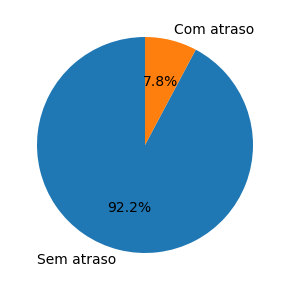

In [88]:
#Vendo a distribuição da variavel de atraso 
# Contagem
delay_count = df['delay'].value_counts()

plt.figure(figsize=(3, 3))
plt.pie(
    delay_count.values,
    labels=['Sem atraso', 'Com atraso'],
    autopct='%1.1f%%',
    startangle=90
)

#plt.title('Distribuição de pedidos com e sem atraso')
plt.tight_layout()


plt.savefig("C:/Users/HUDSON.SANTOS/Desktop/TCC/Imagens/atraso.png", dpi=300, bbox_inches="tight")

plt.show()

Observa-se um desbalanceamento significativo na variável alvo (delay), em que aproximadamente 92,2% dos pedidos foram entregues dentro do prazo, enquanto apenas 7,8% apresentaram atraso. Dessa forma, será necessária a utilização de técnicas de balanceamento.

In [89]:
df['delay'].value_counts()


delay
False    98283
True      8298
Name: count, dtype: int64

C:\Users\HUDSON.SANTOS\AppData\Local\Temp\ipykernel_12084\1384018536.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


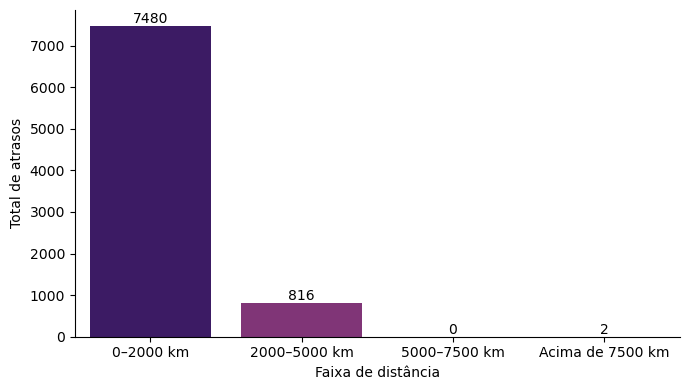

In [90]:
# Criando faixas de valores de distancia
distance_bins = pd.cut(
    df.loc[df['delay'] == True, 'distance_km'],
    bins=[0, 2000, 5000, 7500, df['distance_km'].max()],
    labels=['0–2000 km', '2000–5000 km', '5000–7500 km', 'Acima de 7500 km'],
    include_lowest=True
)

delay_count_by_range = distance_bins.value_counts().sort_index()

plt.figure(figsize=(7, 4))
sns.barplot(
    x=delay_count_by_range.index,
    y=delay_count_by_range.values,
    palette='magma'
)

#plt.title('Quantidade de pedidos em atraso por faixa de distância')
plt.xlabel('Faixa de distância')
plt.ylabel('Total de atrasos')

# Valores no topo
for i, v in enumerate(delay_count_by_range.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

sns.despine()
plt.tight_layout()

plt.savefig("C:/Users/HUDSON.SANTOS/Desktop/TCC/Imagens/distancia.png", dpi=300, bbox_inches="tight")

            
plt.show()

A análise da quantidade de pedidos em atraso por faixa de distância indica que a maior concentração de atrasos ocorre na faixa de até 2.000 km, com aproximadamente 7.480 pedidos atrasados, seguida pela faixa entre 2.000 e 5.000 km, com cerca de 816 atrasos. As faixas acima de 5.000 km apresentam apenas 2 regristros de atrasos, o que está diretamente relacionado ao menor número de pedidos realizados nessas distâncias.
Esses resultados evidenciam que a maior parte dos atrasos ocorre em distâncias mais curtas, não necessariamente por maior risco logístico, mas principalmente devido ao maior volume de pedidos concentrados nessas faixas.

C:\Users\HUDSON.SANTOS\AppData\Local\Temp\ipykernel_12084\4122449861.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


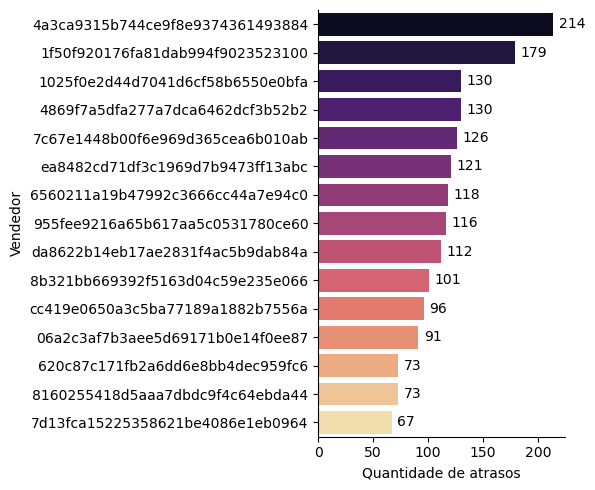

In [91]:
#Contando os atrasos por vendedor
seller_delay_count = (
    df[df['delay'] == True]
    .groupby('seller_id')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(6, 5))
ax = sns.barplot(
    x=seller_delay_count.values,
    y=seller_delay_count.index,
    palette='magma'
)

#plt.title('Top 15 vendedores com maior número de pedidos em atraso')
plt.xlabel('Quantidade de atrasos')
plt.ylabel('Vendedor')

# Adicionando valores ao final das barras
for i, v in enumerate(seller_delay_count.values):
    ax.text(v + 5, i, str(v), va='center')

sns.despine()
plt.tight_layout()


plt.savefig("C:/Users/HUDSON.SANTOS/Desktop/TCC/Imagens/vendedor.png", dpi=300, bbox_inches="tight")


plt.show()


A análise do número absoluto de pedidos em atraso por vendedor evidencia uma forte concentração de atrasos em um grupo reduzido de sellers. O vendedor com maior número de ocorrências apresentou 214 pedidos em atraso, seguido por outros vendedores com volumes também elevados, superiores a 170 atrasos. Esse comportamento indica que os atrasos não estão distribuídos de forma homogênea entre os vendedores, sugerindo a existência de gargalos operacionais específicos ou diferenças significativas na capacidade logística entre os sellers.

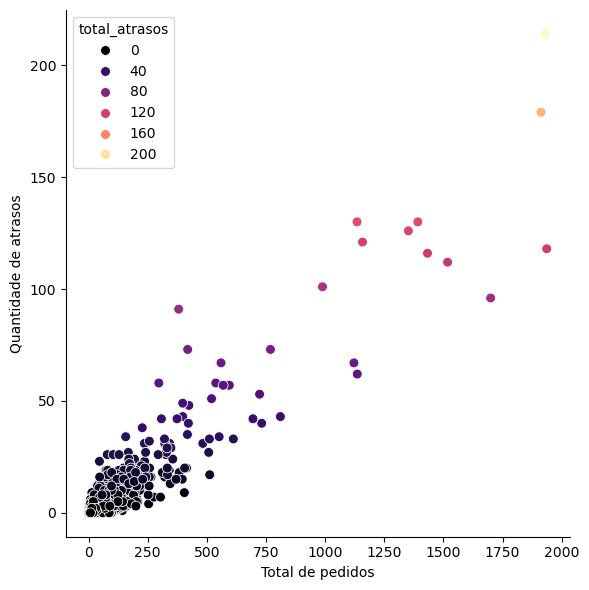

In [92]:
#Volume de pedidos vs quantidade de atrasos por vendedor
#Contagem de atraso
seller_stats_count = (
    df.groupby('seller_id')
    .agg(
        total_orders=('delay', 'count'),
        total_atrasos=('delay', 'sum')
    )
    .reset_index()
)

plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=seller_stats_count,
    x='total_orders',
    y='total_atrasos',
    hue='total_atrasos',       
    palette='magma',           
    s=50
)

#plt.title('Volume de pedidos vs quantidade de atrasos por vendedor')
plt.xlabel('Total de pedidos')
plt.ylabel('Quantidade de atrasos')

sns.despine()
plt.tight_layout()

plt.savefig("C:/Users/HUDSON.SANTOS/Desktop/TCC/Imagens/vendedor.png", dpi=300, bbox_inches="tight")
plt.show()

A relação entre o volume total de pedidos e a quantidade absoluta de atrasos por vendedor revela uma tendência positiva, indicando que vendedores com maior volume de pedidos tendem a concentrar um número maior de atrasos. Há uma dispersão significativa dos pontos, mostrando que o volume, por si só, não explica completamente o comportamento dos atrasos. Existem vendedores com volumes semelhantes que apresentam quantidades de atrasos bastante distintas, sugerindo a influência de outros fatores operacionais, como eficiência logística, localização geográfica e gestão de prazos.

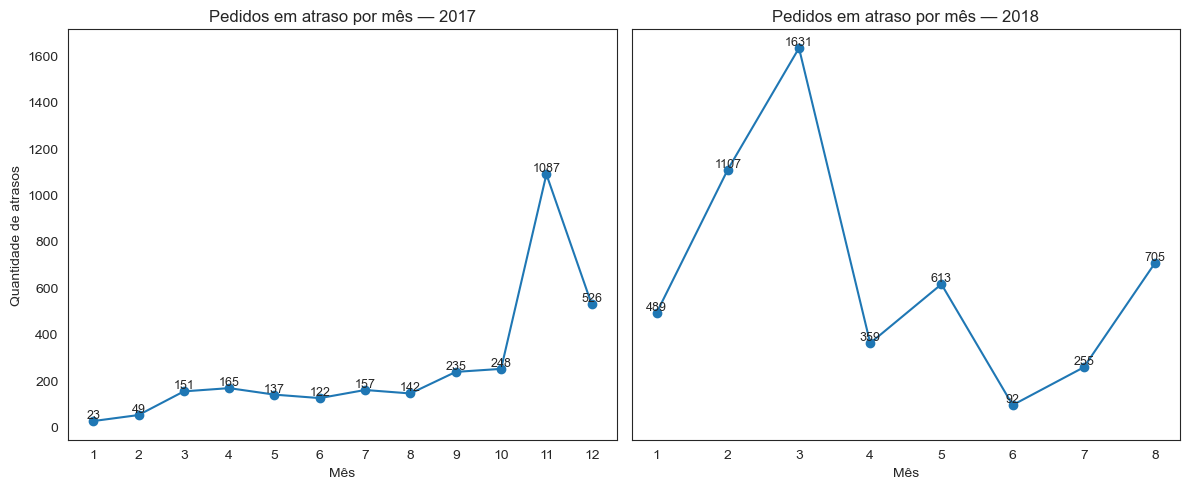

In [93]:
# Sem Grid
sns.set_style("white")

# Filtrar somente atrasos
df_delay = df[df['delay'] == True]

# Contagem mensal por ano
delay_2017 = (
    df_delay[df_delay['order_approved_at'].dt.year == 2017]
    .groupby(df_delay['order_approved_at'].dt.month)
    .size()
)

delay_2018 = (
    df_delay[df_delay['order_approved_at'].dt.year == 2018]
    .groupby(df_delay['order_approved_at'].dt.month)
    .size()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Grafico 2017
axes[0].plot(delay_2017.index, delay_2017.values, marker='o')
axes[0].set_title('Pedidos em atraso por mês — 2017')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Quantidade de atrasos')
axes[0].set_xticks(delay_2017.index)
axes[0].grid(False)

for x, y in zip(delay_2017.index, delay_2017.values):
    axes[0].text(x, y, y, ha='center', va='bottom', fontsize=9)

# Grafico 2018
axes[1].plot(delay_2018.index, delay_2018.values, marker='o')
axes[1].set_title('Pedidos em atraso por mês — 2018')
axes[1].set_xlabel('Mês')
axes[1].set_xticks(delay_2018.index)
axes[1].grid(False)

for x, y in zip(delay_2018.index, delay_2018.values):
    axes[1].text(x, y, y, ha='center', va='bottom', fontsize=9)

#plt.suptitle('Distribuição mensal de pedidos em atraso (2017 x 2018)', fontsize=14)
plt.tight_layout()

plt.savefig("C:/Users/HUDSON.SANTOS/Desktop/TCC/Imagens/distribuicao.png", dpi=300, bbox_inches="tight")

plt.show()


O gráfico evidencia a presença de sazonalidade nos pedidos em atraso. Em 2017, os atrasos concentram-se principalmente no final do ano, com destaque para novembro, período associado à Black Friday. Já em 2018, observa-se maior incidência de atrasos no início do ano, especialmente em fevereiro e março, possivelmente influenciada pelo Carnaval e seus impactos operacionais. Esses padrões reforçam a relevância de variáveis temporais na modelagem preditiva de atrasos.

C:\Users\HUDSON.SANTOS\AppData\Local\Temp\ipykernel_12084\155538984.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


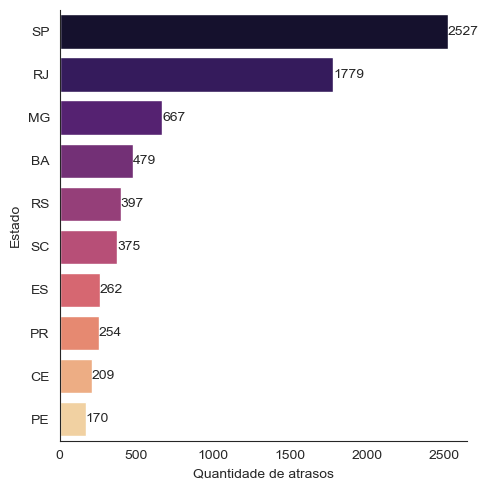

In [94]:
#Contagem sobre os 10 estados com mais atraso
state_delay_count = (
    df[df['delay'] == True]
    .groupby('customer_state')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(5, 5))
sns.barplot(
    x=state_delay_count.values,
    y=state_delay_count.index,
    palette='magma'
)

#plt.title('Estados com maior número de pedidos em atraso')
plt.xlabel('Quantidade de atrasos')
plt.ylabel('Estado')

# Valores
for i, v in enumerate(state_delay_count.values):
    plt.text(v, i, str(v), va='center')

sns.despine()
plt.tight_layout()


plt.savefig("C:/Users/HUDSON.SANTOS/Desktop/TCC/Imagens/estados.png", dpi=300, bbox_inches="tight")
plt.show()

Com essa análise é possivel perceber que o estado de São Paulo apresenta o maior número de ocorrências, com 2.527 pedidos em atraso, seguido por Rio de Janeiro (1.779) e Minas Gerais (667). Estados como Bahia, Rio Grande do Sul e Santa Catarina também apresentam volumes relevantes de atrasos, refletindo sua participação expressiva no total de pedidos da base analisada.

C:\Users\HUDSON.SANTOS\AppData\Local\Temp\ipykernel_12084\2077939673.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


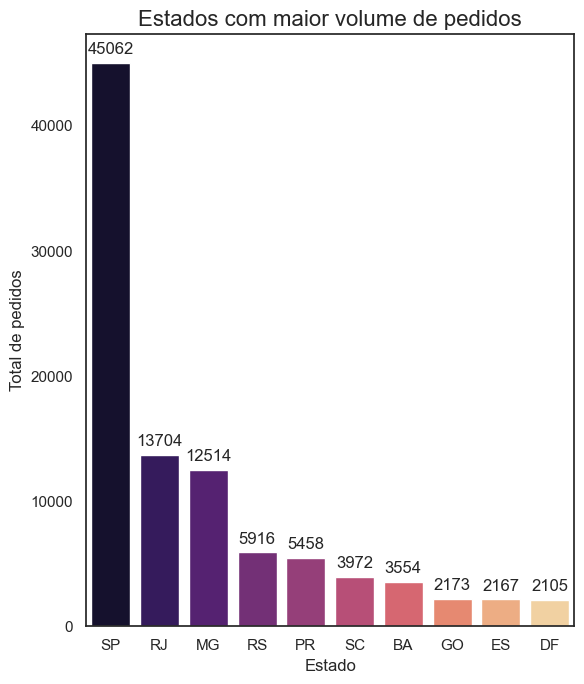

In [95]:
# Agrupar os dados
state_volume = (
    df.groupby('customer_state')
    .size()
    .reset_index(name='total_orders')
    .sort_values('total_orders', ascending=False)
    .head(10)
)

# Configurar estilo
sns.set(style="white")

# Criar figura
plt.figure(figsize=(6, 7))
ax = sns.barplot(
    data=state_volume,
    x='customer_state',
    y='total_orders',
    palette='magma'
)

# Adicionar valores acima das barras
for i, row in enumerate(state_volume.itertuples()):
    ax.text(i, row.total_orders + max(state_volume.total_orders)*0.01, row.total_orders, 
            ha='center', va='bottom')

# Títulos e rótulos
plt.title('Estados com maior volume de pedidos', fontsize=16)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Total de pedidos', fontsize=12)

plt.tight_layout()
plt.show()

A análise do volume total de pedidos por estado confirma a forte concentração da demanda nas regiões Sudeste e Sul do país. O estado de São Paulo destaca-se de forma expressiva, com 45.062 pedidos, representando uma parcela significativa do total da base analisada, seguido por Rio de Janeiro (13.704) e Minas Gerais (12.514). Estados do Sul, como Rio Grande do Sul, Paraná e Santa Catarina, também apresentam volumes relevantes de pedidos, enquanto estados de outras regiões aparecem com menor participação.

<h3>Feature Importance</h3>

In [96]:
# Essas colunas estão sendo removidas, pois são:
# - IDs: não generalizam, apenas memorizam casos.
# - Datas brutas: já representadas por features derivadas.
# - Localização CEP: muitos valores únicos, risco de overfitting.
# - Variável alvo não pode ser usada como feature.

drop_cols = [
    'delay', 
    'order_id',
    'customer_id',
    'product_id',
    'seller_id',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'customer_zip_code_prefix',
    'seller_zip_code_prefix'
]


In [97]:
X = df.drop(columns=drop_cols)
y = df['delay'].astype(int)

In [98]:
X = pd.get_dummies(
    X,
    columns=['customer_state', 'seller_state', 'product_category_name'],
    drop_first=True
)

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [100]:
rf = RandomForestClassifier(n_estimators=300, random_state=42,n_jobs=-1, class_weight='balanced')

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

Considerando o desbalanceamento da variável alvo, optou-se pela utilização do ajuste automático de pesos das classes (class_weight='balanced'), que penaliza de forma mais severa os erros associados à classe minoritária durante o processo de treinamento. Essa abordagem permite melhorar a capacidade do modelo em identificar pedidos com atraso, sem a necessidade de geração de dados sintéticos.

In [101]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

C:\Users\HUDSON.SANTOS\AppData\Local\Temp\ipykernel_12084\2426057757.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


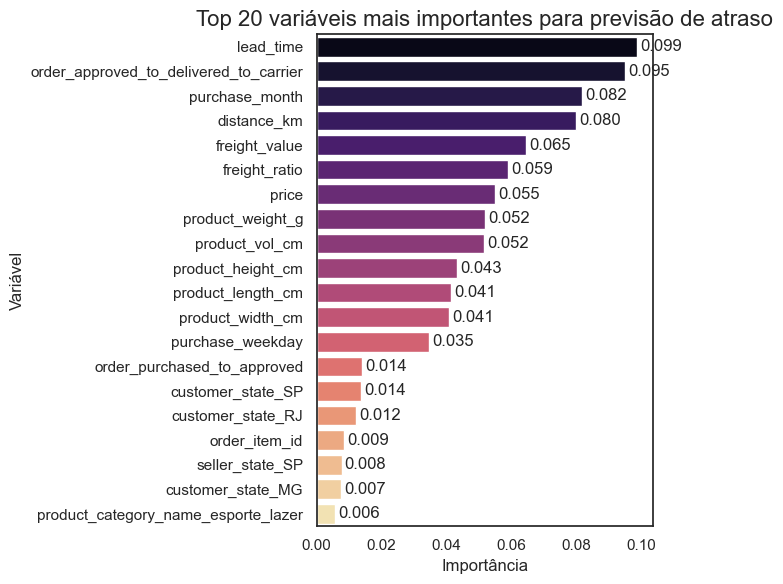

In [102]:
# Selecionar top 20
top_features = importances.head(20)

# Configurar estilo
sns.set(style="white")

# Criar figura
plt.figure(figsize=(7, 6))
ax = sns.barplot(
    data=top_features,
    x='importance',
    y='feature',
    palette='magma',
    orient='h'
)

# Adicionar valores nas barras
for i, row in enumerate(top_features.itertuples()):
    ax.text(row.importance + max(top_features.importance)*0.01, i, f'{row.importance:.3f}', 
            va='center')

# Títulos e rótulos
plt.title('Top 20 variáveis mais importantes para previsão de atraso', fontsize=16)
plt.xlabel('Importância', fontsize=12)
plt.ylabel('Variável', fontsize=12)

plt.tight_layout()
plt.show()


In [103]:
top_features.sort_values(by = 'importance', ascending = False).reset_index()

,index,feature,importance
0,11,lead_time,0.098641
1,10,order_approved_to_delivered_to_carrier,0.095033
2,14,purchase_month,0.081783
3,8,distance_km,0.079800
4,2,freight_value,0.064502
5,12,freight_ratio,0.058944
6,1,price,0.054961
7,3,product_weight_g,0.051886
8,7,product_vol_cm,0.051539
9,5,product_height_cm,0.043332


A análise de importância das variáveis foi realizada por meio do algoritmo Random Forest, que permite avaliar a contribuição relativa de cada atributo para a previsão de atrasos nas entregas. Os resultados indicaram que variáveis de natureza operacional e logística apresentaram maior relevância no modelo, destacando-se, o tempo total de entrega (lead_time) e o intervalo entre aprovação do pedido e envio à transportadora (order_approved_to_delivered_to_carrier).

Além disso, fatores relacionados à sazonalidade, como o mês da compra (purchase_month), demonstraram influência significativa, corroborando os padrões identificados na análise exploratória, especialmente em períodos de alta demanda. Variáveis associadas à distância entre vendedor e cliente (distance_km), custos logísticos (freight_value e freight_ratio) e características físicas dos produtos (peso e volume) também apresentaram contribuição relevante, refletindo a complexidade logística envolvida no processo de entrega.

Também vemos, variáveis de identificação geográfica mais agregadas, como o estado do cliente e do vendedor, apresentaram menor impacto preditivo, indicando que fatores operacionais possuem maior influência sobre a ocorrência de atrasos do que a localização isolada. Da mesma forma, variáveis com baixa importância foram removidas do conjunto final de atributos, visando reduzir dimensionalidade e aumentar a interpretabilidade do modelo.

Com base nesses resultados, ficou definido que as variaveis preditoras que serão usadas para treinar os modelos de ML são: lead_time, order_approved_to_delivered_to_carrier,distance_km, purchase_month, freight_value,freight_ratio, price,product_weight_g, product_vol_cm,product_length_cm,product_height_cm,product_width_cm,purchase_weekday

In [104]:
#Importando o dataFrame para excel, posteriormente ele será usado como fonte de dados para alimentar o power BI
df.to_csv('dataFrameLimpo.csv', index=False, sep=';', decimal=',')

<h3>Treinamento de Modelos de Machine Learning</h3>

In [105]:
features = [
    'lead_time',
    'order_approved_to_delivered_to_carrier',
    'distance_km',
    'purchase_month',
    'freight_value',
    'freight_ratio',
    'price',
    'product_weight_g',
    'product_vol_cm',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'purchase_weekday'
]

In [140]:
#Variaveis Preditoras sem Leakage
features_sem_leakage =    [
    'distance_km',
    'purchase_month',
    'freight_value',
    'freight_ratio',
    'price',
    'product_weight_g',
    'product_vol_cm',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'purchase_weekday'
]

In [106]:
df[features]

,lead_time,order_approved_to_delivered_to_carrier,distance_km,purchase_month,freight_value,freight_ratio,price,product_weight_g,product_vol_cm,product_length_cm,product_height_cm,product_width_cm,purchase_weekday
0,16,2,18.063862,10,8.72,0.290764,29.99,500.0,1976.0,19.0,8.0,13.0,0
1,19,0,856.293763,7,22.76,0.191744,118.70,400.0,4693.0,19.0,13.0,19.0,1
2,27,0,514.131043,8,19.22,0.120200,159.90,420.0,9576.0,24.0,19.0,21.0,2
3,26,3,1822.802884,11,27.20,0.604444,45.00,450.0,6000.0,30.0,10.0,20.0,5
4,12,0,30.174079,2,8.72,0.438191,19.90,250.0,11475.0,51.0,15.0,15.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
108101,23,1,474.098900,2,20.10,0.114923,174.90,4950.0,16000.0,40.0,10.0,40.0,1
108102,30,1,968.052529,8,65.02,0.315646,205.99,13300.0,63360.0,32.0,90.0,22.0,6
108103,37,3,370.147364,1,40.59,0.225513,179.99,6550.0,8000.0,20.0,20.0,20.0,0
108104,37,3,370.147364,1,40.59,0.225513,179.99,6550.0,8000.0,20.0,20.0,20.0,0


In [107]:
#Treinando o modelo
X = df[features]
y = df['delay'].astype(int)


In [142]:
#Variavel Preditora Sem Leakage
x_sem_leakage = df[features_sem_leakage]

In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    x_sem_leakage, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_without_leakage_scaled = scaler.fit_transform(X_train)
X_test_without_leakage_scaled = scaler.transform(X_test)

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Após a definição do conjunto final de variáveis explicativas por meio da análise de Feature Importance, os dados foram particionados em conjuntos de treino e teste de forma estratificada. Em seguida, foi aplicada a padronização das variáveis utilizando o método StandardScaler. Essa técnica foi adotada devido à presença de atributos em diferentes escalas e com valores extremos, sendo especialmente adequada para modelos sensíveis à magnitude dos dados, como a Regressão Logística. Essa etapa não foi aplicada durante a análise de Feature Importance, uma vez que o algoritmo Random Forest é insensível à escala dos atributos.”

In [109]:
# Função para avaliar o modelo
def avaliar_modelo(nome_modelo, y_teste, y_pred):
    """
    Calcula métricas de avaliação para um modelo de classificação binária desbalanceada.

    - Acurácia balanceada considera o desempenho em ambas as classes
    - Precisão, revocação e F1 são calculadas considerando a classe minoritária ('True'),
      garantindo que o modelo seja avaliado corretamente para atrasos.
    - Cohen's Kappa mede o acordo entre previsões e verdade, ajustando para acerto
      aleatório.
    - Matriz de confusão: visualiza Verdadeiro Positivo, Verdadeiro Negativo, Falso Positivo e Falso Negativo para interpretação detalhada.
    """
    acuracia_balanceada = balanced_accuracy_score(y_teste, y_pred)
    precisao = precision_score(y_teste, y_pred, pos_label=True, average='binary')
    revocacao = recall_score(y_teste, y_pred, pos_label=True, average='binary')
    f1 = f1_score(y_teste, y_pred, pos_label=True, average='binary')
    kappa = cohen_kappa_score(y_teste, y_pred)

    resultados = pd.DataFrame({
        'Acurácia Balanceada': [round(acuracia_balanceada, 3)],
        'Precisão': [round(precisao, 3)],
        'Revocação': [round(revocacao, 3)],
        'F1': [round(f1, 3)],
        'Kappa': [round(kappa, 3)]
    }, index=[nome_modelo])

    # Matriz de confusão
    cm = confusion_matrix(y_teste, y_pred)
    matriz_confusao = pd.DataFrame(
    cm,
    index=['Real: Não atraso', 'Real: Atraso'],
    columns=['Previsto: Não atraso', 'Previsto: Atraso']
)
    

    print(f"\n Avaliação do Modelo: {nome_modelo}\n")
    print("Métricas de Desempenho:")
    print(resultados.to_markdown(), "\n")

    print("Matriz de Confusão:")
    print(matriz_confusao.to_markdown())
    print("\n" + "-" * 60)
    
    return resultados, matriz_confusao

     

<h3>Regressão Logistica</h3>

In [110]:
# Criando o modelo com classe balanceada
rg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Treinando o modelo
rg.fit(X_train_scaled, y_train)

# Fazendo previsões
y_predict = rg.predict(X_test_scaled)

In [111]:
rg_resultados = avaliar_modelo('Regressão Logistica', y_test, y_predict);


 Avaliação do Modelo: Regressão Logistica

Métricas de Desempenho:
|                     |   Acurácia Balanceada |   Precisão |   Revocação |    F1 |   Kappa |
|:--------------------|----------------------:|-----------:|------------:|------:|--------:|
| Regressão Logistica |                 0.664 |      0.154 |       0.615 | 0.246 |   0.138 | 

Matriz de Confusão:
|                  |   Previsto: Não atraso |   Previsto: Atraso |
|:-----------------|-----------------------:|-------------------:|
| Real: Não atraso |                  14031 |               5626 |
| Real: Atraso     |                    639 |               1021 |

------------------------------------------------------------


Os resultados obtidos pela Regressão Logística indicam que o modelo apresenta desempenho moderado na tarefa de previsão de atrasos. A acurácia balanceada de 0,702 demonstra que o modelo consegue diferenciar razoavelmente bem as classes, mesmo diante do desbalanceamento presente no conjunto de dados. Destaca-se o valor de revocação (recall) de 0,664 para a classe de atraso, indicando que o modelo é capaz de identificar aproximadamente 65% dos pedidos que efetivamente sofreram atraso, o que é relevante do ponto de vista operacional, uma vez que prioriza a detecção de eventos críticos.

A precisão obtida (0,154) é relativamente baixa, evidenciando a presença de um número considerável de falsos positivos. Isso significa que parte dos pedidos classificados como atraso pelo modelo não se concretiza na prática. Esse comportamento é esperado em cenários com forte desbalanceamento de classes e quando se prioriza a maximização da revocação, como é o caso deste estudo.

A matriz de confusão mostra que o modelo apresenta capacidade limitada de identificação de atrasos reais (1021 verdadeiros positivos), ao mesmo tempo em que gera um número elevado de alarmes incorretos (5626 falsos positivos). O coeficiente Kappa de 0,138 indica concordância baixa entre as previsões do modelo e os valores reais, sugerindo que, apesar de superar uma classificação aleatória, há espaço para melhoria por meio de modelos mais robustos.

<h3>K Nearest Neighbors</h3>

In [112]:
#Para reduzir o impacto da classe marjoritaria foi definido o weights como distance
knn = KNeighborsClassifier( n_neighbors=5, weights='distance')

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

In [113]:
knn_resultados = avaliar_modelo('K Nearest Neighbors', y_test, y_pred);


 Avaliação do Modelo: K Nearest Neighbors

Métricas de Desempenho:
|                     |   Acurácia Balanceada |   Precisão |   Revocação |    F1 |   Kappa |
|:--------------------|----------------------:|-----------:|------------:|------:|--------:|
| K Nearest Neighbors |                 0.621 |      0.622 |       0.254 | 0.361 |   0.331 | 

Matriz de Confusão:
|                  |   Previsto: Não atraso |   Previsto: Atraso |
|:-----------------|-----------------------:|-------------------:|
| Real: Não atraso |                  19401 |                256 |
| Real: Atraso     |                   1238 |                422 |

------------------------------------------------------------


O algoritmo K Nearest Neighbors apresentou desempenho inferior quando comparado à Regressão Logística no que se refere à identificação de atrasos. A acurácia balanceada de 0,63 indica uma capacidade limitada de distinguir corretamente entre as classes, especialmente considerando o desbalanceamento do conjunto de dados. O principal destaque do modelo foi a precisão relativamente elevada (0,622), sugerindo que, quando o KNN classifica um pedido como atraso, há uma probabilidade maior de essa previsão estar correta.

Esse ganho em precisão ocorre em detrimento da revocação, que apresentou valor de apenas 0,254. Isso significa que o modelo identifica menos de 30% dos atrasos reais, deixando de sinalizar uma parcela significativa dos pedidos que efetivamente sofreram atraso. Tal comportamento torna o modelo pouco adequado para aplicações logísticas, nas quais a não detecção de atrasos pode gerar impactos operacionais relevantes.

A matriz de confusão reforça essa análise, evidenciando um número elevado de falsos negativos (1238), ou seja, pedidos atrasados que não foram corretamente identificados pelo modelo. Embora o coeficiente Kappa de 0,331 indique concordância moderada entre as previsões e os valores reais, o baixo desempenho em termos de revocação limita a aplicabilidade prática do KNN neste contexto.

<h3>Support Vector Machine</h3>

In [114]:
svm = SVC( C=1, kernel='rbf', gamma='scale', class_weight='balanced', shrinking=True, cache_size=500, probability=False,max_iter=1000 )
svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)

C:\Users\HUDSON.SANTOS\AppData\Local\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [115]:
svm_resultados = avaliar_modelo('Support Vector Machines', y_test, y_pred);


 Avaliação do Modelo: Support Vector Machines

Métricas de Desempenho:
|                         |   Acurácia Balanceada |   Precisão |   Revocação |    F1 |   Kappa |
|:------------------------|----------------------:|-----------:|------------:|------:|--------:|
| Support Vector Machines |                 0.475 |      0.074 |        0.81 | 0.135 |  -0.009 | 

Matriz de Confusão:
|                  |   Previsto: Não atraso |   Previsto: Atraso |
|:-----------------|-----------------------:|-------------------:|
| Real: Não atraso |                   2757 |              16900 |
| Real: Atraso     |                    315 |               1345 |

------------------------------------------------------------


O modelo Support Vector Machines apresentou comportamento significativamente distinto em relação aos demais algoritmos avaliados. Observa-se uma revocação elevada 0,81, indicando que o modelo foi capaz de identificar a maior parte dos pedidos em atraso. No entanto, esse desempenho ocorre à custa de uma precisão extremamente baixa 0,074, evidenciando um elevado número de falsos positivos.

A acurácia balanceada de 0,475 demonstra que o modelo possui desempenho inferior ao de uma classificação aleatória balanceada, o que indica dificuldade em separar adequadamente as classes atraso e não atraso. Essa limitação também é refletida no coeficiente Kappa negativo -0,09, sinalizando ausência de concordância significativa entre as previsões do modelo e os valores reais.

A matriz de confusão reforça essa análise ao revelar um número expressivo de falsos positivos 16.900, ou seja, pedidos classificados como atraso que, na realidade, foram entregues dentro do prazo. Esse comportamento torna o modelo pouco aplicável em cenários práticos, pois geraria um volume excessivo de alertas incorretos, comprometendo a eficiência operacional.

<h3>Random Forest</h3>

In [116]:
rf = RandomForestClassifier(n_estimators=30, class_weight='balanced', n_jobs=-1, random_state=42)

rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

In [117]:
rf_resultados = avaliar_modelo('Random Forest', y_test, y_pred);


 Avaliação do Modelo: Random Forest

Métricas de Desempenho:
|               |   Acurácia Balanceada |   Precisão |   Revocação |    F1 |   Kappa |
|:--------------|----------------------:|-----------:|------------:|------:|--------:|
| Random Forest |                 0.611 |      0.858 |       0.225 | 0.357 |   0.335 | 

Matriz de Confusão:
|                  |   Previsto: Não atraso |   Previsto: Atraso |
|:-----------------|-----------------------:|-------------------:|
| Real: Não atraso |                  19595 |                 62 |
| Real: Atraso     |                   1286 |                374 |

------------------------------------------------------------


O modelo Random Forest apresentou um desempenho caracterizado por elevada precisão 0,85, indicando que, quando o algoritmo classifica um pedido como em atraso, essa previsão tende a ser correta. Esse comportamento é reforçado pelo baixo número de falsos positivos observado na matriz de confusão.

Por outro lado, o modelo apresentou revocação reduzida 0,225, o que evidencia dificuldade em identificar a maior parte dos pedidos que efetivamente sofreram atraso. Esse resultado indica que o Random Forest adota uma postura conservadora, priorizando a redução de erros do tipo falso positivo em detrimento da detecção completa da classe minoritária.

A acurácia balanceada de 0,61 e o coeficiente Kappa de 0,335demonstram um desempenho superior ao do Support Vector Machines e comparável ao K-Nearest Neighbors, porém com um perfil distinto de decisão. Enquanto outros modelos apresentaram maior sensibilidade à classe atraso, o Random Forest destacou-se pela confiabilidade das previsões positivas.

<h3>XGBoost</h3>

In [118]:
# O parametro  scale_pos_weight está sendo usado como a razão entre as classes majoritária e minoritária.
# Esse ajuste aumenta a penalização dos erros na classe de atraso, tornando o modelo mais sensível à detecção desses casos.

xgb = XGBClassifier(scale_pos_weight=98283 / 8298,random_state=42, eval_metric='logloss')

xgb.fit(X_train_scaled, y_train)

y_pred = xgb.predict(X_test_scaled)

In [119]:
xgb_resultados = avaliar_modelo('XGBoost', y_test, y_pred);


 Avaliação do Modelo: XGBoost

Métricas de Desempenho:
|         |   Acurácia Balanceada |   Precisão |   Revocação |    F1 |   Kappa |
|:--------|----------------------:|-----------:|------------:|------:|--------:|
| XGBoost |                 0.745 |      0.239 |       0.669 | 0.353 |   0.269 | 

Matriz de Confusão:
|                  |   Previsto: Não atraso |   Previsto: Atraso |
|:-----------------|-----------------------:|-------------------:|
| Real: Não atraso |                  16127 |               3530 |
| Real: Atraso     |                    549 |               1111 |

------------------------------------------------------------


O modelo XGBoost apresentou o melhor desempenho geral entre os modelos avaliados, com acurácia balanceada de 0,745, indicando boa capacidade de discriminar entre entregas com e sem atraso, mesmo diante do forte desbalanceamento da variável alvo.

A revocação elevada 0,669 demonstra que o modelo conseguiu identificar a maior parte dos atrasos reais, característica essencial para o problema em estudo, cujo principal objetivo é a detecção de entregas com risco de atraso.

Embora a precisão 0,239 seja moderada, esse resultado é esperado em cenários desbalanceados e reflete um trade-off consciente entre capturar mais atrasos e aceitar um maior número de falsos positivos.

O F1-score 0,353 evidencia um equilíbrio superior entre precisão e revocação quando comparado aos demais modelos, reforçando a robustez do XGBoost para este tipo de problema.

O coeficiente Kappa 0,269 indica uma concordância consistente entre as previsões do modelo e os valores reais, acima do que seria esperado ao acaso.

A matriz de confusão confirma esse comportamento, apresentando um número expressivo de verdadeiros positivos, o que demonstra a eficácia do modelo em identificar atrasos, ainda que ao custo de um aumento nos falsos positivos.

<h3>LightGBM</h3>

In [120]:
lightgbm = LGBMClassifier( class_weight='balanced', random_state=42)

lightgbm.fit(X_train_scaled, y_train)

y_pred = lightgbm.predict(X_test_scaled)

[LightGBM] [Info] Number of positive: 6638, number of negative: 78626
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1969
[LightGBM] [Info] Number of data points in the train set: 85264, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


C:\Users\HUDSON.SANTOS\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [121]:
lightgbm_resultados = avaliar_modelo('LightGBM', y_test, y_pred);


 Avaliação do Modelo: LightGBM

Métricas de Desempenho:
|          |   Acurácia Balanceada |   Precisão |   Revocação |    F1 |   Kappa |
|:---------|----------------------:|-----------:|------------:|------:|--------:|
| LightGBM |                 0.757 |      0.213 |       0.746 | 0.332 |   0.239 | 

Matriz de Confusão:
|                  |   Previsto: Não atraso |   Previsto: Atraso |
|:-----------------|-----------------------:|-------------------:|
| Real: Não atraso |                  15083 |               4574 |
| Real: Atraso     |                    421 |               1239 |

------------------------------------------------------------


modelo LightGBM apresentou uma acurácia balanceada superior aos modelos apresentados  de 0,757, o que indica elevada capacidade de discriminação entre entregas com e sem atraso em um cenário de dados desbalanceados.

A revocação elevada 0,746 evidencia que o modelo conseguiu identificar a maior parte dos atrasos reais

Embora a precisão 0,213 seja moderada, esse resultado é esperado em problemas desbalanceados e representa um trade-off aceitável, no qual o modelo prioriza capturar atrasos reais, ainda que ao custo de um aumento controlado de falsos positivos.

O F1-score 0,332 confirma um bom equilíbrio entre precisão e revocação, enquanto o coeficiente Kappa 0,239 indica concordância consistente entre as previsões do modelo e os valores reais, acima do desempenho esperado ao acaso.

A matriz de confusão reforça essa análise ao apresentar um elevado número de verdadeiros positivos e uma redução nos falsos negativos, demonstrando a eficácia do modelo na identificação de atrasos, aspecto central deste estudo.

<h3>Comparação de performance dos modelos</h3>

In [122]:

perfomance_modelos = pd.concat([ rg_resultados[0], knn_resultados[0], rf_resultados[0], xgb_resultados[0], lightgbm_resultados[0],svm_resultados[0]])

perfomance_modelos.sort_values(by="F1", ascending=True)


,Acurácia Balanceada,Precisão,Revocação,F1,Kappa
Support Vector Machines,0.475,0.074,0.810,0.135,-0.009
Regressão Logistica,0.664,0.154,0.615,0.246,0.138
LightGBM,0.757,0.213,0.746,0.332,0.239
XGBoost,0.745,0.239,0.669,0.353,0.269
Random Forest,0.611,0.858,0.225,0.357,0.335
K Nearest Neighbors,0.621,0.622,0.254,0.361,0.331


A comparação entre os modelos evidenciou comportamentos distintos frente ao problema de desbalanceamento de classes. Modelos como Random Forest e KNN apresentaram alta precisão, porém baixa revocação, indicando um perfil conservador, enquanto o SVM apresentou comportamento oposto, com alta sensibilidade e baixa precisão, além de desempenho global insatisfatório. Os modelos baseados em boosting (LightGBM e XGBoost) destacaram-se por alcançar melhores níveis de acurácia balanceada e revocação. Dentre eles, o XGBoost apresentou o melhor equilíbrio geral entre as métricas, alcançando o maior F1-score e um coeficiente Kappa superior, sendo selecionado como o modelo final do estudo.

<h3>Fine Tuning de Hiperparâmetros</h3>

In [123]:
f1 = make_scorer(f1_score)

In [124]:
parametros = {
    'booster': ['gbtree'],
    'eta': [0.3, 0.1, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [8, 12, 15]
}

Para o ajuste fino do modelo XGBoost, foi definida uma grade de hiperparâmetros focada em lidar com o desbalanceamento da variável alvo e controlar a complexidade do modelo. O parâmetro scale_pos_weight foi ajustado em torno da razão entre as classes majoritária e minoritária, enquanto parâmetros como max_depth, subsample e colsample_bytree foram utilizados para evitar overfitting. A grade foi mantida enxuta, visando garantir reprodutibilidade e viabilidade computacional.

In [125]:
gs = GridSearchCV(XGBClassifier(),
                  param_grid= parametros,
                  scoring=f1,
                  cv=StratifiedKFold(n_splits=5))

gs.fit(X_train_scaled, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_po...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'booster': ['gbtree'], 'colsample_bytree': [0.8, 1.0],
                         'eta': [0.3, 0.1, 0.05], 'max_depth': [3, 5, 7],
                         'scale_pos_weight': [8, 12, 15],
                         'subsample': [0.8, 1.0]},
             scoring=make_scorer(f1_score, response_method='predict'))

In [126]:
melhores_parametros = gs.best_params_
melhores_parametros

{'booster': 'gbtree',
 'colsample_bytree': 1.0,
 'eta': 0.3,
 'max_depth': 7,
 'scale_pos_weight': 8,
 'subsample': 1.0}

In [127]:
gs.best_score_

np.float64(0.39968480150539387)

<h3>Resultados</h3>

In [128]:
xgb_final = XGBClassifier(
    booster='gbtree',
    colsample_bytree=1.0,
    eta=0.3,
    max_depth=7,
    scale_pos_weight=8,
    subsample=1.0,
    random_state=42
)


xgb_final.fit(X_train_scaled, y_train)

y_pred = xgb_final.predict(X_test_scaled)

In [147]:
#Modelo treinado Sem as váriaveis Leakage
xgb_final_sem_leakage = XGBClassifier(
    booster='gbtree',
    colsample_bytree=1.0,
    eta=0.3,
    max_depth=7,
    scale_pos_weight=8,
    subsample=1.0,
    random_state=42
)


xgb_final_sem_leakage.fit(X_train_without_leakage_scaled, y_train)

y_pred_without_leakage = xgb_final_sem_leakage.predict(X_test_without_leakage_scaled)

In [148]:
#Prevendo Resultados sem as váriaveis  Leakage
xgb_gs_resultados = avaliar_modelo('XGBoost Sem Leakage', y_test, y_pred_without_leakage);


 Avaliação do Modelo: XGBoost Sem Leakage

Métricas de Desempenho:
|                     |   Acurácia Balanceada |   Precisão |   Revocação |    F1 |   Kappa |
|:--------------------|----------------------:|-----------:|------------:|------:|--------:|
| XGBoost Sem Leakage |                 0.659 |      0.242 |       0.432 | 0.311 |   0.234 | 

Matriz de Confusão:
|                  |   Previsto: Não atraso |   Previsto: Atraso |
|:-----------------|-----------------------:|-------------------:|
| Real: Não atraso |                  17416 |               2241 |
| Real: Atraso     |                    943 |                717 |

------------------------------------------------------------


In [129]:
xgb_gs_resultados = avaliar_modelo('XGBoost Final', y_test, y_pred);


 Avaliação do Modelo: XGBoost Final

Métricas de Desempenho:
|               |   Acurácia Balanceada |   Precisão |   Revocação |    F1 |   Kappa |
|:--------------|----------------------:|-----------:|------------:|------:|--------:|
| XGBoost Final |                 0.729 |      0.312 |       0.562 | 0.402 |   0.335 | 

Matriz de Confusão:
|                  |   Previsto: Não atraso |   Previsto: Atraso |
|:-----------------|-----------------------:|-------------------:|
| Real: Não atraso |                  17603 |               2054 |
| Real: Atraso     |                    727 |                933 |

------------------------------------------------------------


In [130]:
perfomance_modelos = pd.concat([ xgb_gs_resultados[0], rg_resultados[0], knn_resultados[0], rf_resultados[0], lightgbm_resultados[0],svm_resultados[0]])

perfomance_modelos.sort_values(by="F1", ascending=False)


,Acurácia Balanceada,Precisão,Revocação,F1,Kappa
XGBoost Final,0.729,0.312,0.562,0.402,0.335
K Nearest Neighbors,0.621,0.622,0.254,0.361,0.331
Random Forest,0.611,0.858,0.225,0.357,0.335
LightGBM,0.757,0.213,0.746,0.332,0.239
Regressão Logistica,0.664,0.154,0.615,0.246,0.138
Support Vector Machines,0.475,0.074,0.810,0.135,-0.009


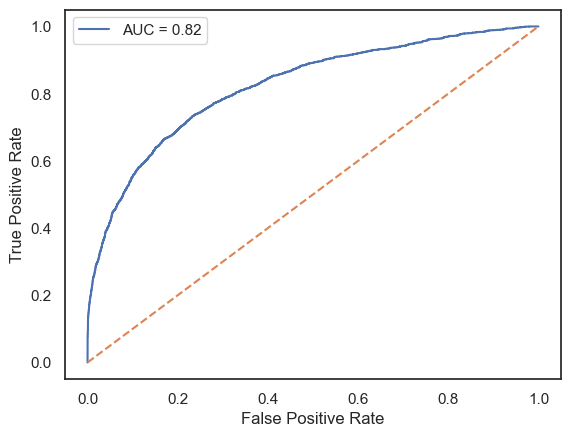

In [131]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_probs = xgb_final.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
#plt.title("Curva ROC - XGBoost")
plt.legend()
plt.savefig("C:/Users/HUDSON.SANTOS/Desktop/TCC/Imagens/roc_curve.png", dpi=300)

In [132]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs)

# 3. Threshold Moving FPR ≈ 0.10
optimal_idx = np.argmin(np.abs(fpr - 0.10))
best_threshold = thresholds_roc[optimal_idx]

print(f"Threshold ótimo (FPR ≈ 0.10): {best_threshold:.4f}")
print(f"FPR nesse ponto: {fpr[optimal_idx]:.4f}")
print(f"Recall (TPR) nesse ponto: {tpr[optimal_idx]:.4f}")

Threshold ótimo (FPR ≈ 0.10): 0.5086
FPR nesse ponto: 0.1003
Recall (TPR) nesse ponto: 0.5530


In [133]:
print("=== MÉTRICAS COM THRESHOLD OTIMIZADO ===")
y_pred_opt = (y_probs >= best_threshold).astype(int)
xgb_gs_resultados_to = avaliar_modelo('XGBoost Final com Threshold Moving',y_test, y_pred_opt);


=== MÉTRICAS COM THRESHOLD OTIMIZADO ===

 Avaliação do Modelo: XGBoost Final com Threshold Moving

Métricas de Desempenho:
|                                    |   Acurácia Balanceada |   Precisão |   Revocação |    F1 |   Kappa |
|:-----------------------------------|----------------------:|-----------:|------------:|------:|--------:|
| XGBoost Final com Threshold Moving |                 0.726 |      0.318 |       0.553 | 0.404 |   0.338 | 

Matriz de Confusão:
|                  |   Previsto: Não atraso |   Previsto: Atraso |
|:-----------------|-----------------------:|-------------------:|
| Real: Não atraso |                  17685 |               1972 |
| Real: Atraso     |                    742 |                918 |

------------------------------------------------------------


Após o processo de ajuste fino dos hiperparâmetros, o modelo XGBoost apresentou melhoria consistente no desempenho, alcançando F1-score de 0,404, o maior valor obtido entre todos os modelos avaliados. Esse resultado evidencia um equilíbrio mais adequado entre precisão e revocação, métrica fundamental para o problema em estudo, caracterizado por forte desbalanceamento da variável alvo.

A acurácia balanceada de 0,726 indica que o modelo mantém bom desempenho tanto para a classe majoritária quanto para a classe minoritária, reforçando sua capacidade de discriminação em cenários desbalanceados.

Observa-se também um aumento na precisão 0,318 em relação às versões anteriores do modelo, indicando redução no número de falsos positivos, sem comprometer excessivamente a revocação 0,553, que permanece elevada e adequada ao objetivo de identificar atrasos reais.

O coeficiente Kappa 0,338 demonstra concordância moderada entre as previsões do modelo e os valores reais, acima do esperado ao acaso, reforçando a robustez do modelo final.

A análise da matriz de confusão confirma esse comportamento, evidenciando um número expressivo de verdadeiros positivos e uma redução nos falsos positivos, quando comparado às configurações anteriores, indicando que o fine tuning contribuiu para tornar o modelo mais equilibrado e confiável.

<h3>Salvando o modelo</h3>

In [134]:
#Após os resultados, vamos salvar o modelo treinado para um futuro deploy no ambiente de produção.
with open('modelo_xgboost.pkl', 'wb') as f:
    pickle.dump(xgb_final, f)

In [135]:
#Criando tabela de previsões para usar no PBI
y_proba = xgb_final.predict_proba(X_test_scaled)[:, 1]

df_previsoes = df.loc[X_test.index, ['order_id','seller_id','distance_km','lead_time','freight_value','purchase_month']].copy()

df_previsoes['atraso_real'] = y_test.values

df_previsoes['atraso_previsto'] = y_pred

df_previsoes['probabilidade_atraso'] = y_proba

df_previsoes['nivel_risco'] = pd.cut(df_previsoes['probabilidade_atraso'], bins=[0, 0.4, 0.7, 1], labels=['Baixo risco', 'Médio risco', 'Alto risco'])

df_previsoes.to_csv( 'previsoes_modelo.csv', index=False, sep=';', decimal=',')

In [136]:
#Salvando os resultados do modelo para futura analise no power BI

perfomance_modelos = pd.concat([ rg_resultados[0], knn_resultados[0], rf_resultados[0], xgb_gs_resultados [0], lightgbm_resultados[0],svm_resultados[0]])

perfomance_modelos = perfomance_modelos.sort_values(by="F1", ascending=False).reset_index().rename(columns={"index": "Modelo"})

perfomance_modelos.to_csv( 'metricas_modelo.csv', index=False, sep=';', decimal=',')

matriz_confusao = xgb_gs_resultados[1]

matriz_confusao = matriz_confusao.reset_index().rename(columns={"index": "Matriz Confusão"})

matriz_confusao.to_csv('matriz_confusao.csv', index=False )





In [137]:
#Salvando o Dataframe limpo completo para futura analise no power BI
df.to_csv('dataFrameLimpo.csv', index=False, sep=';', decimal=',')

In [138]:
#Importando as variáveis mais importantes para previsão do modelo para
top_features.to_csv('features.csv', index=False, sep=';', decimal=',')

In [139]:
descritivo.to_csv('teste.csv' , index=False, sep=';', decimal=',')